In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data/raw/reviews_raw.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (2209, 8)
Columns: ['review_id', 'review_text', 'star_rating', 'date', 'app_id', 'app_category', 'category_label', 'category_name']


,review_id,review_text,star_rating,date,app_id,app_category,category_label,category_name
0,570b5412-5b91-48bb-8c06-963879515606,Android (Oxygen OS 16): home screen widget is ...,1,2026-06-16 18:22:10,com.todoist,productivity,0,Bug Report
1,515ec419-cce5-41da-aaff-5779f2031805,EDIT: I reached out to support as advised in t...,2,2026-06-16 16:36:06,com.todoist,productivity,1,Feature Request
2,75f42825-a30b-4237-9afe-c051a23b6e63,"not working on oneplus 9rt , can't login",1,2026-06-16 16:35:08,com.todoist,productivity,0,Bug Report
3,aa395a6b-07b5-422e-960e-e1317436b2ac,Yesterday I mentioned that a task disappeared ...,1,2026-06-16 03:31:49,com.todoist,productivity,0,Bug Report
4,41f403b4-c9a4-4bc3-bc29-756df20edac7,"Installed it, created an account, realized I n...",1,2026-06-15 19:18:12,com.todoist,productivity,2,UX Feedback


In [3]:
print('=== Dataset Overview ===')
print(f'Total reviews:     {len(df)}')
print(f'Unique apps:       {df["app_id"].nunique()}')
print(f'App categories:    {df["app_category"].nunique()}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nStar rating distribution:')
print(df['star_rating'].value_counts().sort_index())

=== Dataset Overview ===
Total reviews:     2209
Unique apps:       11
App categories:    5
Missing values:
review_id         0
review_text       0
star_rating       0
date              0
app_id            0
app_category      0
category_label    0
category_name     0
dtype: int64

Star rating distribution:
star_rating
1    860
2    190
3    166
4    156
5    837
Name: count, dtype: int64


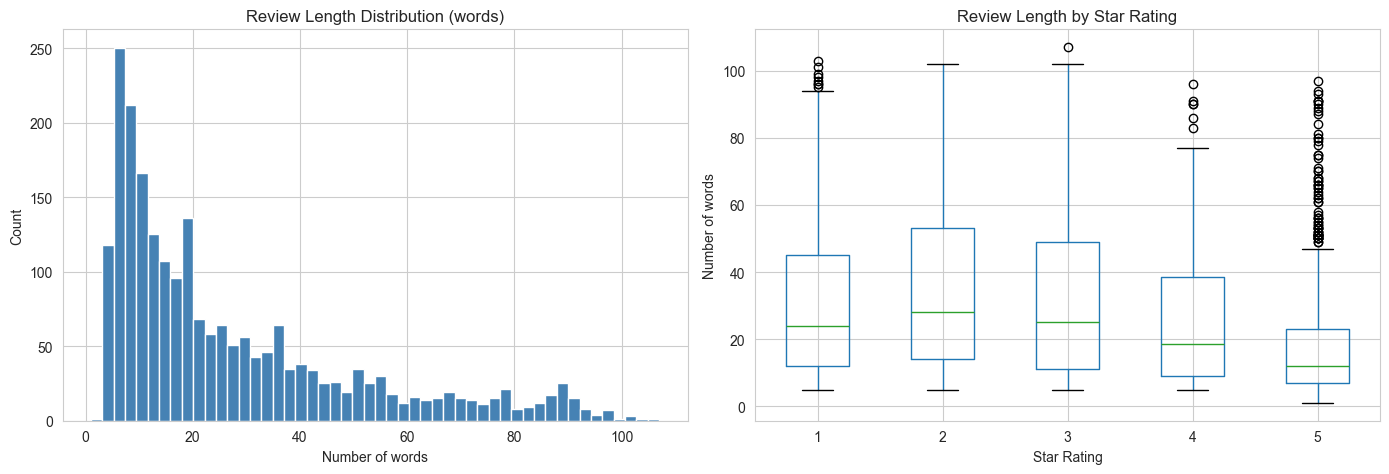

Average review length: 26.9 words
Median review length:  18.0 words
Max review length:     107 words


In [5]:
df['review_length'] = df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Review Length Distribution (words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')

# Boxplot by star rating
df.boxplot(column='review_length', by='star_rating', ax=axes[1])
axes[1].set_title('Review Length by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average review length: {df["review_length"].mean():.1f} words')
print(f'Median review length:  {df["review_length"].median():.1f} words')
print(f'Max review length:     {df["review_length"].max()} words')

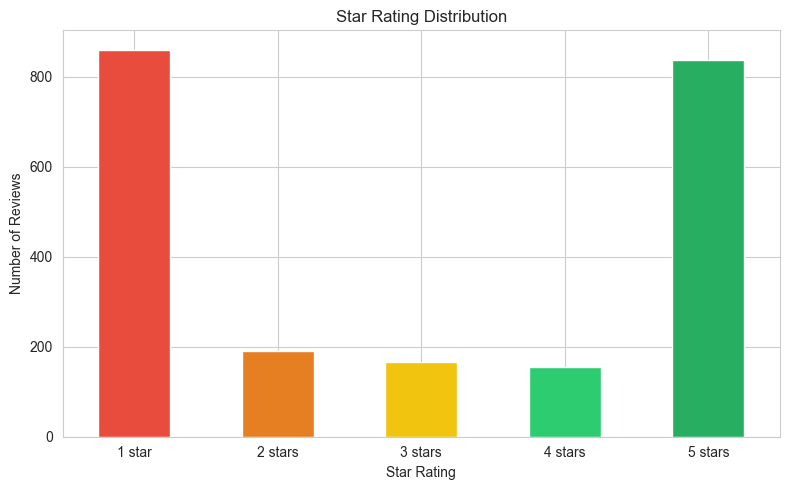

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
df['star_rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Star Rating Distribution')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(['1 star', '2 stars', '3 stars', '4 stars', '5 stars'], rotation=0)
plt.tight_layout()
plt.savefig('../reports/star_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

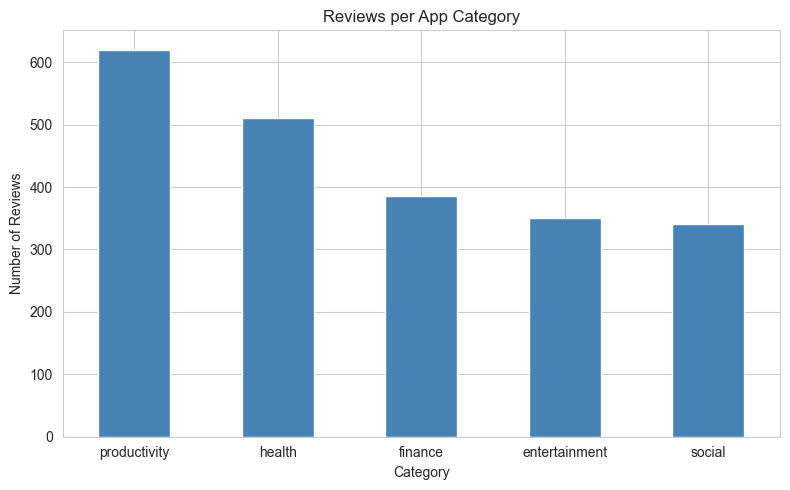

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df['app_category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Reviews per App Category')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/reviews_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

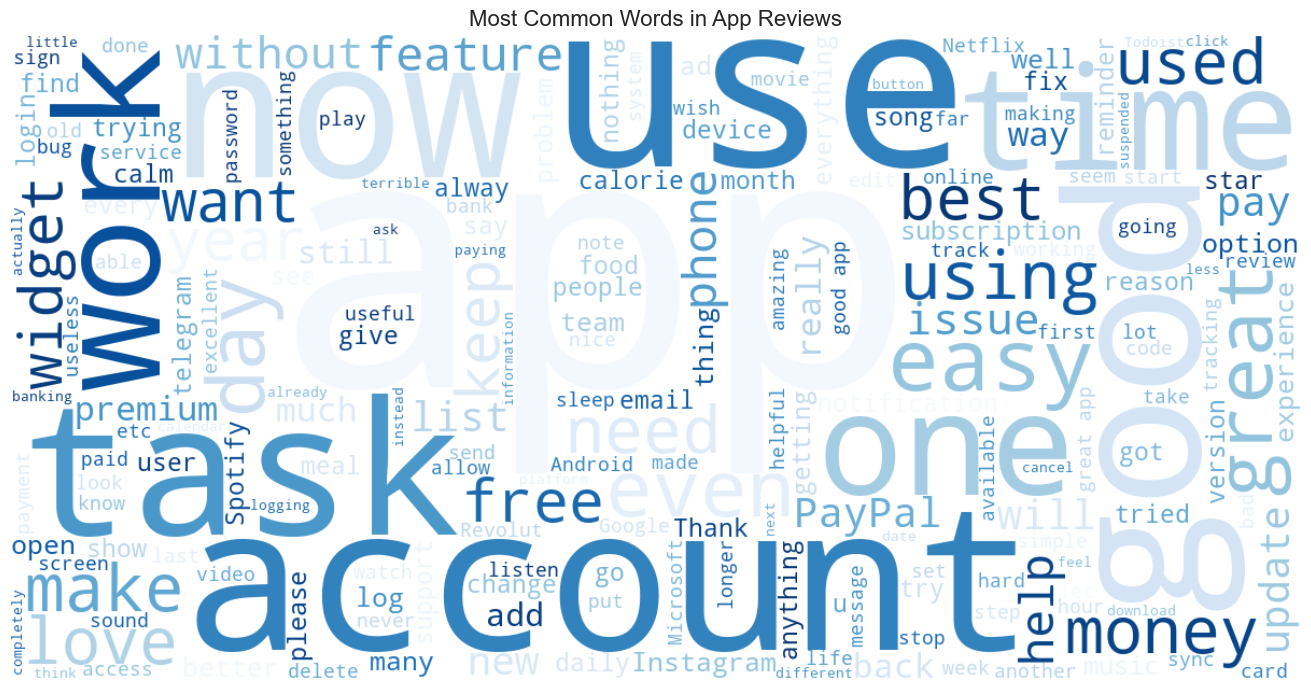

In [8]:
all_text = ' '.join(df['review_text'].tolist())

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=200,
    colormap='Blues'
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in App Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
for rating in [1, 2, 3, 4, 5]:
    sample = df[df['star_rating'] == rating]['review_text'].sample(2, random_state=42).tolist()
    print(f'\n=== {rating} Star Reviews ===')
    for i, text in enumerate(sample, 1):
        print(f'{i}. {text[:200]}...' if len(text) > 200 else f'{i}. {text}')


=== 1 Star Reviews ===
1. can't able to login please help me
2. Instagram, why do you want us to pay you? aren't you earning enough, just like other apps? where is premium coming from? please stop it and work on equality!

=== 2 Star Reviews ===
1. trying to confirm my password from my phone email app but every time I switch out of the PayPal app, it errors and wants me to send another code. so messed up. I need the money in there to combine wit...
2. pls make it available in all country like Ethiopia pls

=== 3 Star Reviews ===
1. works good, new pricing is ridiculous.
2. I was unable to manage my subscription by reversing my request to cancel

=== 4 Star Reviews ===
1. Just started with new update. A great improvement on the last design.
2. my go to for Asian dramas

=== 5 Star Reviews ===
1. Perfect ! easy to work with !
2. The app is great. Best banking services I know. That would be great. + proper monthly account statement pls (PDF) with all transaction details (like an official